In [ ]:
# JupyterLite needs openpyxl to read Excel files
%pip install -q openpyxl

# What is a time series model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
admissions = pd.read_excel('Time_series_data_5_14.xlsx',
                          skiprows = 13,
                          skipfooter = 3)
admissions.head()

,Unnamed: 0,Year,Period,Beginning of Period,Elective G&A Ordinary Admissions (FFCEs),Elective G&A Daycase Admissions (FFCEs),Elective G&A Total Admissions (FFCEs),Elective G&A Planned Ordinary Admissions (FFCEs),Elective G&A Planned Daycase Admissions (FFCEs),Elective G&A Planned Total Admissions (FFCEs),Elective G&A Admissions (FFCEs) -NHS Treatment Centres (TCs),Total Non-elective G&A Admissions (FFCEs),GP Referrals Made (All specialties),GP Referrals Seen (All specialties),GP Referrals Made (G&A),GP Referrals Seen (G&A),Other Referrals Made (G&A),All 1st Outpatient Attendances (G&A)
0,NaN,2008-09,APRIL,2008-04-01,141966,421825,563791,24225,122080.0,146305.0,14335.0,408413.0,914131.0,762501.0,866763.0,711755.0,459669.0,1189155.0
1,NaN,2008-09,MAY,2008-05-01,138813,393100,531913,22968,118359.0,141327.0,15691.0,419542.0,858883.0,698646.0,820730.0,657553.0,441589.0,1105267.0
2,NaN,2008-09,JUNE,2008-06-01,139990,406636,546626,21983,118809.0,140792.0,13583.0,408705.0,886572.0,755628.0,845108.0,713978.0,461013.0,1187592.0
3,NaN,2008-09,JULY,2008-07-01,149480,437984,587464,24208,127610.0,151818.0,16778.0,424751.0,944448.0,793814.0,901783.0,753847.0,483791.0,1247964.0
4,NaN,2008-09,AUGUST,2008-08-01,133957,378081,512038,22179,111894.0,134073.0,15041.0,404388.0,816623.0,671458.0,777762.0,629963.0,413372.0,1057369.0


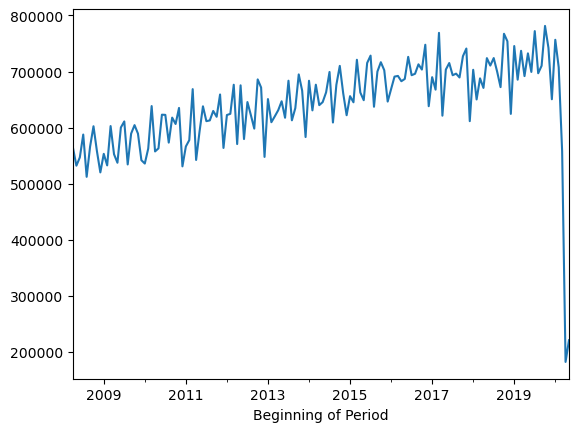

In [3]:
import matplotlib.pyplot as plt
elective_surgeries = admissions['Elective G&A Total Admissions (FFCEs)']
elective_surgeries.index = admissions['Beginning of Period']
elective_surgeries.plot();

In [4]:
elective_surgeries = elective_surgeries.asfreq('MS')

# Recognising a Trend

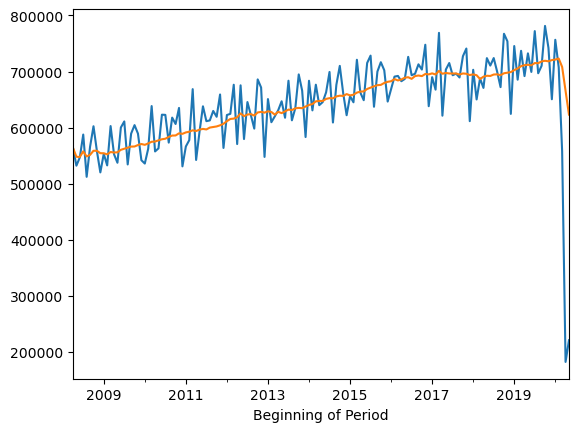

In [5]:
elective_surgeries.plot()
elective_surgeries.rolling(12,min_periods=1).mean().plot();

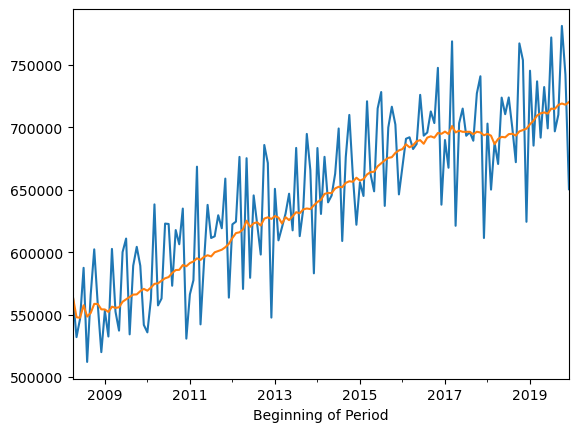

In [6]:
elective_surgeries = elective_surgeries.drop(elective_surgeries.tail(5).index)
elective_surgeries.plot()
elective_surgeries.rolling(12,min_periods=1).mean().plot();

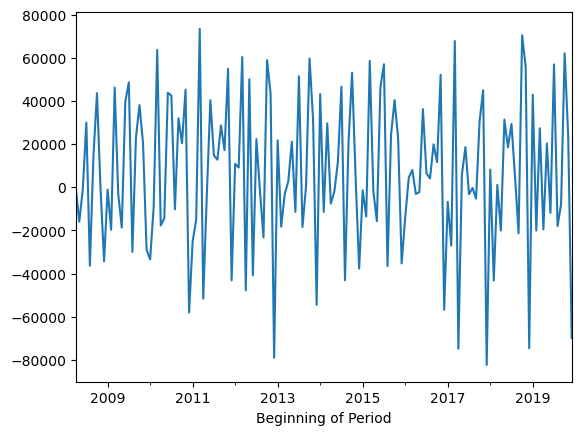

In [7]:
(elective_surgeries - elective_surgeries.rolling(12,min_periods=1).mean()).plot();

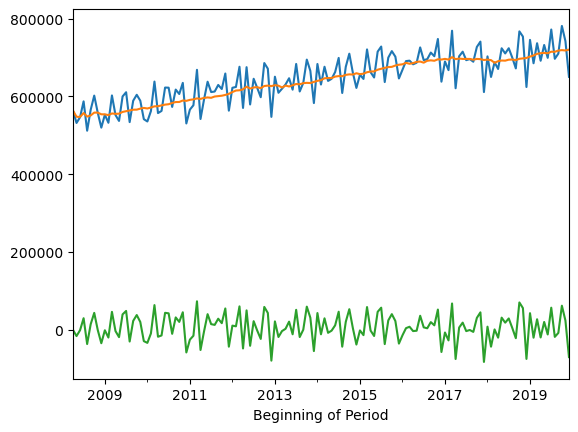

In [8]:
elective_surgeries.plot()
elective_surgeries.rolling(12,min_periods=1).mean().plot()
(elective_surgeries - elective_surgeries.rolling(12,min_periods=1).mean()).plot();

In [9]:
elective_less_trend = (elective_surgeries -
                      elective_surgeries.rolling(12,min_periods=1).mean()).values

In [10]:
admissions = admissions.drop(admissions.tail(5).index)
admissions['Total_Elective_G&A_less_trend'] = elective_less_trend

In [11]:
admissions.head()

,Unnamed: 0,Year,Period,Beginning of Period,Elective G&A Ordinary Admissions (FFCEs),Elective G&A Daycase Admissions (FFCEs),Elective G&A Total Admissions (FFCEs),Elective G&A Planned Ordinary Admissions (FFCEs),Elective G&A Planned Daycase Admissions (FFCEs),Elective G&A Planned Total Admissions (FFCEs),Elective G&A Admissions (FFCEs) -NHS Treatment Centres (TCs),Total Non-elective G&A Admissions (FFCEs),GP Referrals Made (All specialties),GP Referrals Seen (All specialties),GP Referrals Made (G&A),GP Referrals Seen (G&A),Other Referrals Made (G&A),All 1st Outpatient Attendances (G&A),Total_Elective_G&A_less_trend
0,NaN,2008-09,APRIL,2008-04-01,141966,421825,563791,24225,122080.0,146305.0,14335.0,408413.0,914131.0,762501.0,866763.0,711755.0,459669.0,1189155.0,0.000000
1,NaN,2008-09,MAY,2008-05-01,138813,393100,531913,22968,118359.0,141327.0,15691.0,419542.0,858883.0,698646.0,820730.0,657553.0,441589.0,1105267.0,-15939.000000
2,NaN,2008-09,JUNE,2008-06-01,139990,406636,546626,21983,118809.0,140792.0,13583.0,408705.0,886572.0,755628.0,845108.0,713978.0,461013.0,1187592.0,-817.333333
3,NaN,2008-09,JULY,2008-07-01,149480,437984,587464,24208,127610.0,151818.0,16778.0,424751.0,944448.0,793814.0,901783.0,753847.0,483791.0,1247964.0,30015.500000
4,NaN,2008-09,AUGUST,2008-08-01,133957,378081,512038,22179,111894.0,134073.0,15041.0,404388.0,816623.0,671458.0,777762.0,629963.0,413372.0,1057369.0,-36328.400000


# Recognising a seasonality

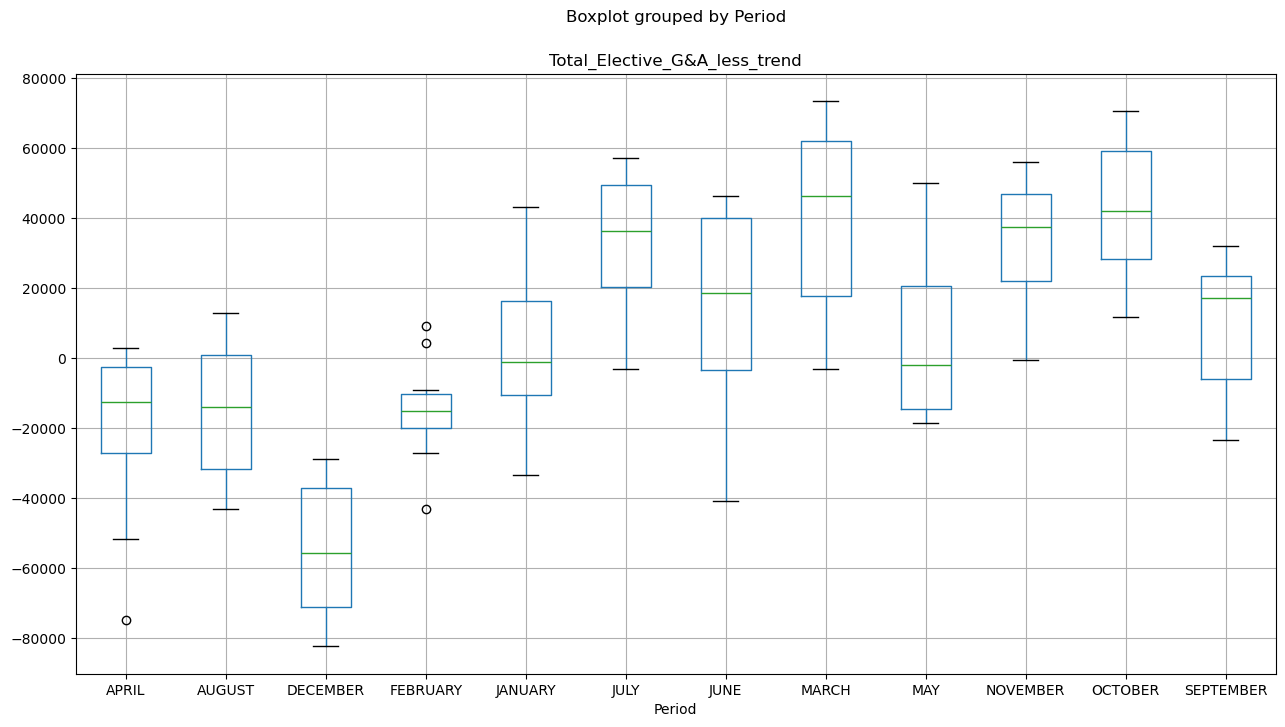

In [12]:
admissions.boxplot(column = 'Total_Elective_G&A_less_trend',by='Period', figsize = (15,8));

In [13]:
# 1. Create a list with the months in chronological order.
month_order = [
    'JANUARY', 'FEBRUARY', 'MARCH', 'APRIL', 'MAY', 'JUNE',
    'JULY', 'AUGUST', 'SEPTEMBER', 'OCTOBER', 'NOVEMBER', 'DECEMBER'
]

# 2. Convert the 'Period' column to a special 'Categorical' type with the correct order.
admissions['Period'] = pd.Categorical(
    admissions['Period'],
    categories=month_order,
    ordered=True
)

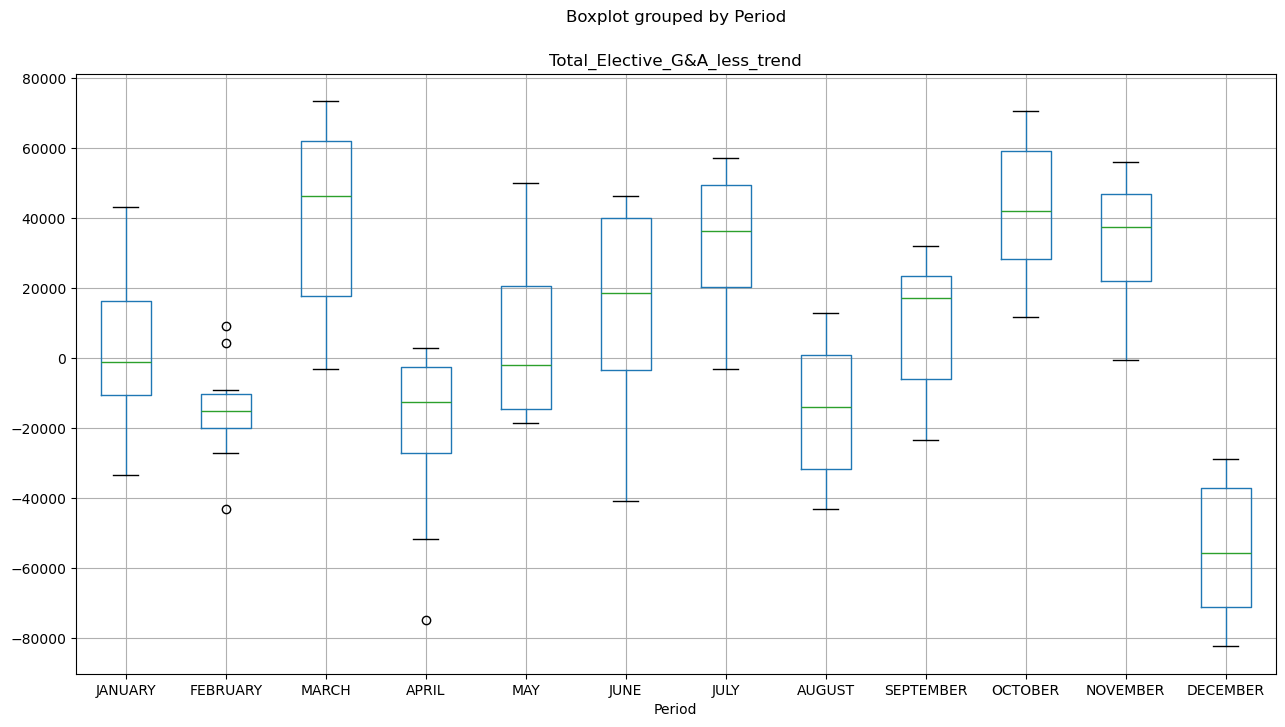

In [14]:
admissions.boxplot(column = 'Total_Elective_G&A_less_trend',by='Period', figsize = (15,8));

# How can we test our model on new data?

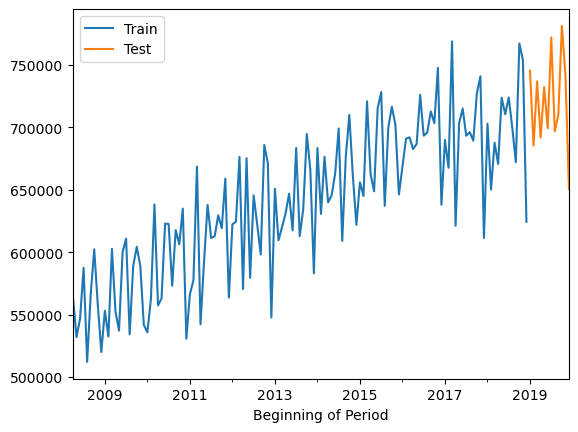

In [15]:
train = elective_surgeries[:'2018']
test = elective_surgeries['2019':]
train.plot(label='Train')
test.plot(label='Test')
plt.legend();

# Building a time series Model

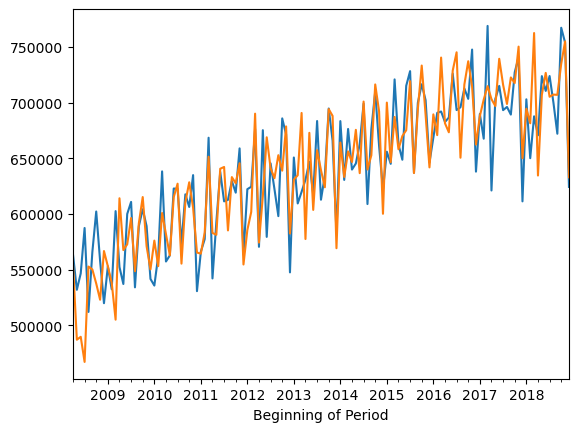

In [16]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

dependent = train.astype('float')

ets_model = ETSModel(dependent, trend = 'add', seasonal = 'add', seasonal_periods = 12).fit()

dependent.plot()

ets_model.fittedvalues.plot();

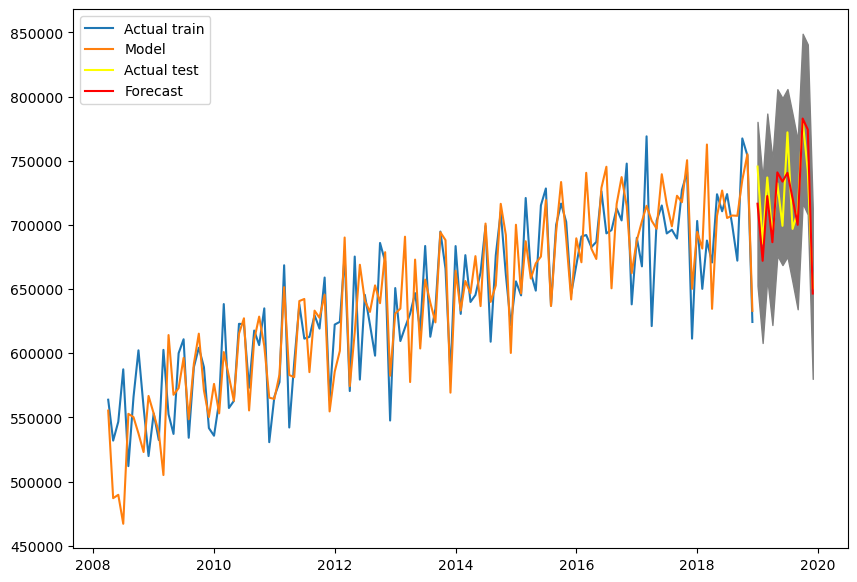

In [17]:
forecast = ets_model.get_prediction(start = '2019-01-01', end = '2019-12-01').summary_frame()

plt.figure(figsize=(10,7))

plt.plot(dependent)
plt.plot(ets_model.fittedvalues)
plt.plot(test, color = 'yellow')
plt.plot(forecast['mean'], color = 'red')

plt.fill_between(forecast.index,
                 forecast['pi_lower'],
                 forecast['pi_upper'],
                 color='grey'
                )

plt.legend(['Actual train','Model', 'Actual test','Forecast']);


In [18]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,mean_squared_error, root_mean_squared_error

MAPE = mean_absolute_percentage_error(test,forecast['mean'])
MAE = mean_absolute_error(test,forecast['mean'])
MSE = mean_squared_error(test,forecast['mean'])
RMSE = root_mean_squared_error(test,forecast['mean'])

print(f'MAPE: {round(MAPE*100)}%')
print(f'MAE: {round(MAE)}')
print(f'MSE: {round(MSE)}')
print(f'RMSE: {round(RMSE)}')


MAPE: 2.0%
MAE: 17349.0
MSE: 435777915.0
RMSE: 20875.0


# Results and next steps

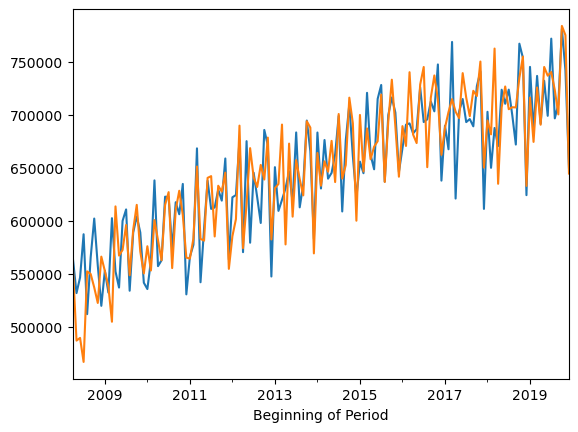

In [19]:
dependent = elective_surgeries.astype('float')

ets_full_model = ETSModel(dependent,
                         trend = 'add',
                         seasonal = 'add',
                         seasonal_periods = 12).fit()

dependent.plot()

ets_full_model.fittedvalues.plot();

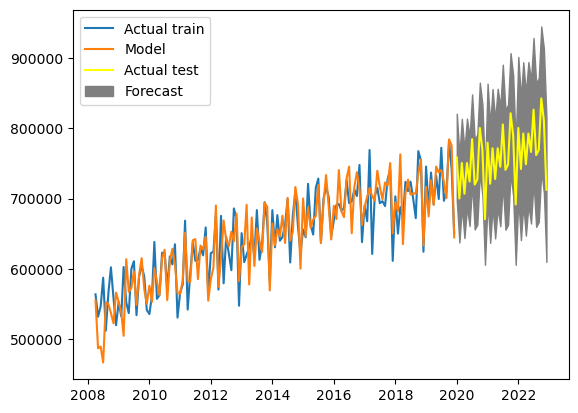

In [22]:
forecast = ets_full_model.get_prediction(start = '2020-01-01', end = '2022-12-01').summary_frame()

plt.plot(dependent)
plt.plot(ets_full_model.fittedvalues)
plt.plot(forecast['mean'], color='yellow')
plt.fill_between(
    forecast.index,
    forecast['pi_lower'],
    forecast['pi_upper'],
    color='grey'
)
plt.legend(['Actual train','Model', 'Actual test','Forecast']);